Found tasks: ['T2', 'T8']

Tasks classified as pain: ['T2']
Tasks classified as no-pain: ['T8']

Class distribution before training:
Total samples: 280
Pain samples (T2): 140
No-pain samples (T8): 140

Training model:


,Fold,F1 Score
0,1,0.819672
1,2,0.700000
2,3,0.866667
3,4,0.750000
4,5,0.774194



Mean CV F1 score: 0.7821 (+/- 0.1145)


,Metric,Value
0,Accuracy,0.8571
1,F1 Score,0.8667


### Confusion Matrix

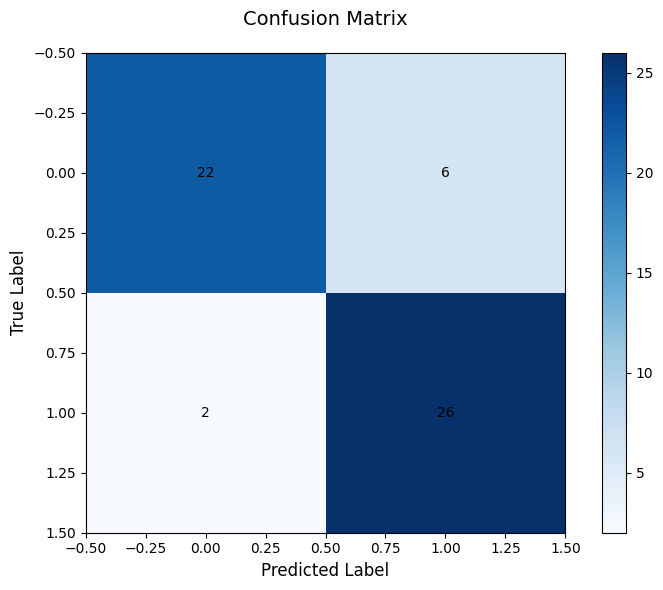

### ROC Curve

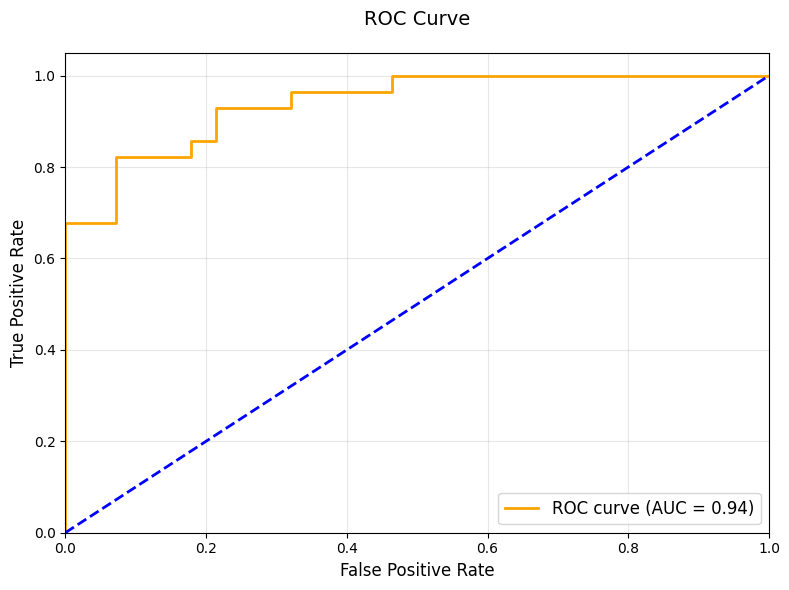

### Feature Importance

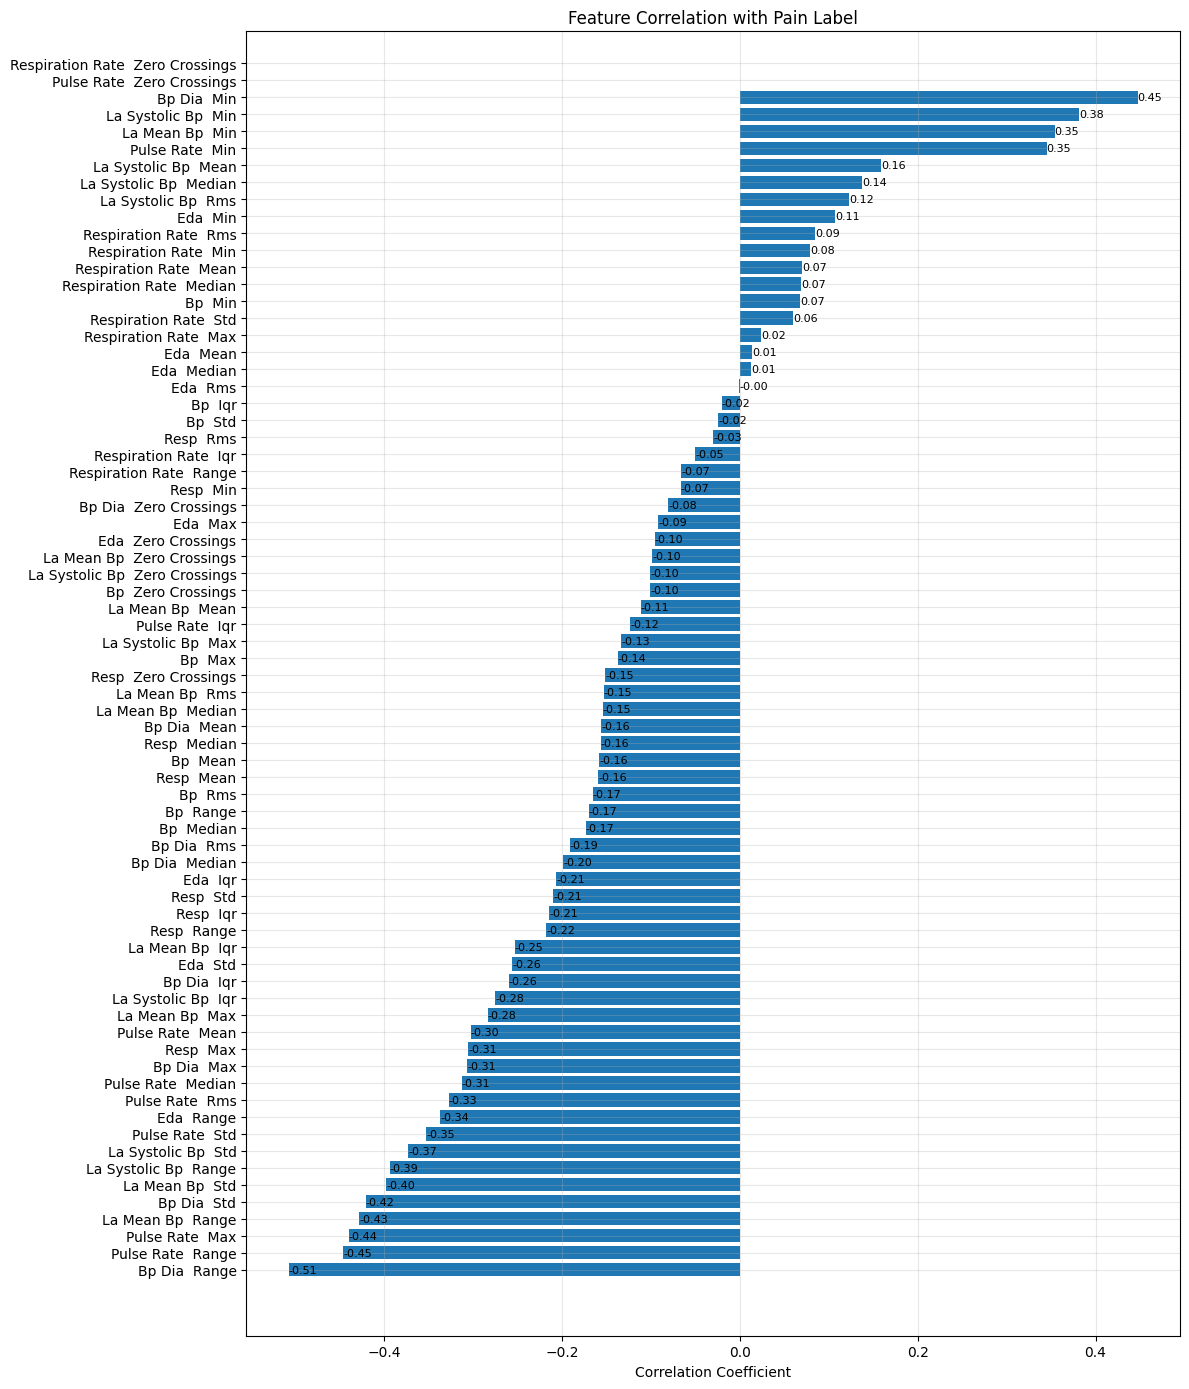

None

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from joblib import dump
from IPython.display import display, HTML
from IPython.display import Markdown
import zipfile
import shutil
#import warnings
#warnings.filterwarnings('ignore')

dataset_path = "/content/BP4D+_PhysiologicalPainNoPain.zip"  # labels the zip

# extracts the zip file info in input is a zip
def unzip(path):
    extract_dir = "/content/extracted_data" # creates output file for zip info
    # extracts the zip file
    with zipfile.ZipFile(path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # look for Dataset1 folder within the extracted content and put it in the extracted data folder
    for item in os.listdir(extract_dir):
        if os.path.isdir(os.path.join(extract_dir, item)) and "Dataset1" in item:
          return os.path.join(extract_dir, item)
    return extract_dir # return the extracted data

# extract the features from the file to be used to analyze the data
def extract_features_from_file(file_path):
    data = np.loadtxt(file_path) # loads data from the text file
    features = { # dictionary extracting the data
        'mean': np.mean(data),
        'std': np.std(data),
        'min': np.min(data),
        'max': np.max(data),
        'median': np.median(data),
        'rms': np.sqrt(np.mean(np.square(data))),
        'zero_crossings': len(np.where(np.diff(np.signbit(data)))[0]),
        'range': np.max(data) - np.min(data),
        'iqr': np.percentile(data, 75) - np.percentile(data, 25)
    }
    return features

# plot confusion matrix with basic matplotlib
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred) # calculate confusion matrix from true and predicted labels
    # plots data
    fig = plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar()
    # adding annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    plt.title(title, fontsize=14, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    return fig

# plot ROC curve
def plot_roc_curve(y_true, y_pred_proba, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)  # calculate false positive and true positive rate with thresholds
    roc_auc = auc(fpr, tpr) # find the area under the curve
    # plots data
    fig = plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, pad=20)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

# plots feature importance using correlation with target
def plot_feature_importance(X, y):
    correlations = X.corrwith(y).sort_values() # calculates correlations between each feature and the target variable
    # renaming features for readability
    feature_names = [feat.replace('_', ' ').replace('mmHg', '').replace('microsiemens', '').replace('BPM', '').replace('Volts', '').title()
                     for feat in correlations.index]
    # plots data
    plt.figure(figsize=(12, 14))
    bars = plt.barh(feature_names, correlations.values)
    # add labels to bars
    for bar in bars:
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2f}', va='center', ha='left', fontsize=8)
    plt.title('Feature Correlation with Pain Label')
    plt.xlabel('Correlation Coefficient')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# prepare the dataset (extract if needed)
dataset_dir =unzip(dataset_path)
all_tasks = set()
task_counts = {}  # to count samples per task
# analyzing what is in the dataset
for subject in os.listdir(dataset_dir):
    subject_path = os.path.join(dataset_dir, subject)
    if os.path.isdir(subject_path):
        for task in os.listdir(subject_path):
            if os.path.isdir(os.path.join(subject_path, task)):
                all_tasks.add(task)
                task_counts[task] = task_counts.get(task, 0) + 1 # counts samples by task
print(f"Found tasks: {sorted(list(all_tasks))}")

# Using T2 as pain and T8 as no-pain to create a balanced classification
pain_tasks = ['T2']
no_pain_tasks = ['T8']
print(f"\nTasks classified as pain: {pain_tasks}")
print(f"Tasks classified as no-pain: {no_pain_tasks}")

all_rows = [] # initialize an empty list to store rows of data
# defines which physiological signal files to process
signals = ['BP Dia_mmHg.txt', 'BP_mmHg.txt', 'EDA_microsiemens.txt',
           'LA Mean BP_mmHg.txt', 'LA Systolic BP_mmHg.txt',
           'Pulse Rate_BPM.txt', 'Resp_Volts.txt', 'Respiration Rate_BPM.txt']

# process each subject and task
for subject in os.listdir(dataset_dir):
    subject_path = os.path.join(dataset_dir, subject)

    for task in os.listdir(subject_path):
        task_path = os.path.join(subject_path, task)
        is_pain = task in pain_tasks # label as pain=1 if task is in pain_tasks, else pain=0
        row = {'subject': subject, 'task': task, 'label': int(is_pain)}

        # extract features for each signal file
        for signal in signals:
            signal_path = os.path.join(task_path, signal)
            if os.path.exists(signal_path):
                # get statistical features from the signal
                features = extract_features_from_file(signal_path)
                if features:
                    # add each feature to the row
                    for key, value in features.items():
                        row[f"{signal.replace('.txt', '')}_{key}"] = value
        all_rows.append(row) # add to dataset

df = pd.DataFrame(all_rows) # create data frame from all rows
df.dropna(inplace=True)  # drop rows with missing values

# print class distribution before proceeding
print("\nClass distribution before training:")
print(f"Total samples: {len(df)}")
print(f"Pain samples (T2): {df['label'].sum()}")
print(f"No-pain samples (T8): {len(df) - df['label'].sum()}")

X = df.drop(columns=['subject', 'task', 'label'])
y = df['label'] # the target pain or no pain

# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# initialize and train the SVM model
print("\nTraining model:")
model = SVC(kernel='rbf', C=1, gamma='scale', probability=True)

# perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

# display cross-validation results
display(HTML("<h2>Cross-validation Results</h2>"))
cv_df = pd.DataFrame({
    'Fold': range(1, 6),
    'F1 Score': cv_scores
})
display(cv_df)
print(f"\nMean CV F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# train the final model
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test) # binary predictions
y_pred_proba = model.predict_proba(X_test)[:, 1] # probabilty scores

# calculate metrics
accuracy = accuracy_score(y_test, y_pred) # correct prediction proportion
f1 = f1_score(y_test, y_pred) #mean

# display final performance
display(HTML("<h2>Final Model Performance</h2>"))
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Value': [f"{accuracy:.4f}", f"{f1:.4f}"]
})
display(performance_df)

# generate visualizations
display(Markdown("### Confusion Matrix"))
cm_fig = plot_confusion_matrix(y_test, y_pred)
display(cm_fig)
plt.close()

# ROC Curve
display(Markdown("### ROC Curve"))
roc_fig = plot_roc_curve(y_test, y_pred_proba)
display(roc_fig)
plt.close()

# feature importance
display(Markdown("### Feature Importance"))
feat_fig = plot_feature_importance(X, y)
display(feat_fig)
plt.close()